# 03 · Baselines

Referencias contra las que medir el MLP, con **el mismo protocolo** del notebook 02
(KFold(5) × 3 semillas sobre `train_dev`, RMSE out-of-fold agrupado).

Sin esto no hay forma de saber si un RMSE de 25 000 es bueno o malo.

In [1]:
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline

sys.path.insert(0, str(Path.cwd().parent))
from src.data import ROOT, load_raw, rmse, split_xy
from src.preprocessing import PreprocessConfig, build_preprocessor

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight"})
FIGURES = ROOT / "reports" / "figures"

SEED, SEMILLAS, N_SPLITS = 42, (42, 43, 44), 5
CFG_PRE = PreprocessConfig()

df = load_raw(ROOT / "data" / "raw" / "train.csv")
X, y = split_xy(df)
split = json.loads((ROOT / "data" / "processed" / "split.json").read_text())
mask_dev = df["Id"].isin(split["id_dev"]).to_numpy()
X_dev, y_dev = X[mask_dev].reset_index(drop=True), y[mask_dev].reset_index(drop=True)
print(f"train_dev: {X_dev.shape} (misma partición congelada del notebook 02)")

train_dev: (992, 79) (misma partición congelada del notebook 02)


In [2]:
def cv_sklearn(estimador, X, y, log_target=True, semillas=SEMILLAS, n_splits=N_SPLITS):
    """Mismo protocolo que el MLP: OOF agrupado, preprocesamiento ajustado dentro del fold."""
    rmses = []
    for s in semillas:
        oof = np.full(len(y), np.nan)
        for i_tr, i_va in KFold(n_splits, shuffle=True, random_state=s).split(X):
            pre = build_preprocessor(CFG_PRE)
            A = pre.fit_transform(X.iloc[i_tr], y.iloc[i_tr])
            B = pre.transform(X.iloc[i_va])
            yt = np.log1p(y.iloc[i_tr]) if log_target else y.iloc[i_tr]
            m = clone(estimador).fit(A, yt)
            p = m.predict(B)
            oof[i_va] = np.expm1(p) if log_target else p
        rmses.append(rmse(y, oof))
    return float(np.mean(rmses)), float(np.std(rmses)), oof


from sklearn.base import clone

modelos = {
    "Media (DummyRegressor)": (DummyRegressor(strategy="mean"), False),
    "Mediana (DummyRegressor)": (DummyRegressor(strategy="median"), False),
    "Ridge (alpha=10)": (Ridge(alpha=10.0), True),
    "ElasticNet": (ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000), True),
    "RandomForest (400)": (RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1), True),
    "GradientBoosting (500)": (GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                        max_depth=3, subsample=0.8,
                                                        random_state=SEED), True),
}

filas = []
for nombre, (est, logt) in modelos.items():
    t0 = time.perf_counter()
    m, s, _ = cv_sklearn(est, X_dev, y_dev, log_target=logt)
    filas.append({"modelo": nombre, "RMSE": m, "std entre semillas": s,
                  "seg": time.perf_counter() - t0})
    print(f"{nombre:<26} {m:>9,.0f} ± {s:>6,.0f}   ({time.perf_counter()-t0:.0f}s)")

baselines = pd.DataFrame(filas).sort_values("RMSE").reset_index(drop=True)

Media (DummyRegressor)        77,786 ±     44   (1s)


Mediana (DummyRegressor)      79,514 ±     50   (1s)


Ridge (alpha=10)              47,042 ± 10,707   (1s)


ElasticNet                    47,258 ± 13,071   (1s)


RandomForest (400)            33,367 ±  1,433   (8s)


GradientBoosting (500)        31,877 ±  2,456   (21s)


In [3]:
baselines["vs. media"] = (1 - baselines["RMSE"] / baselines.loc[
    baselines["modelo"] == "Media (DummyRegressor)", "RMSE"].iloc[0])
baselines.round({"RMSE": 0, "std entre semillas": 0, "seg": 1, "vs. media": 3})

,modelo,RMSE,std entre semillas,seg,vs. media
0,GradientBoosting (500),31877.0,2456.0,20.8,0.590
1,RandomForest (400),33367.0,1433.0,7.9,0.571
2,Ridge (alpha=10),47042.0,10707.0,1.0,0.395
3,ElasticNet,47258.0,13071.0,1.5,0.392
4,Media (DummyRegressor),77786.0,44.0,0.9,0.000
5,Mediana (DummyRegressor),79514.0,50.0,0.8,-0.022


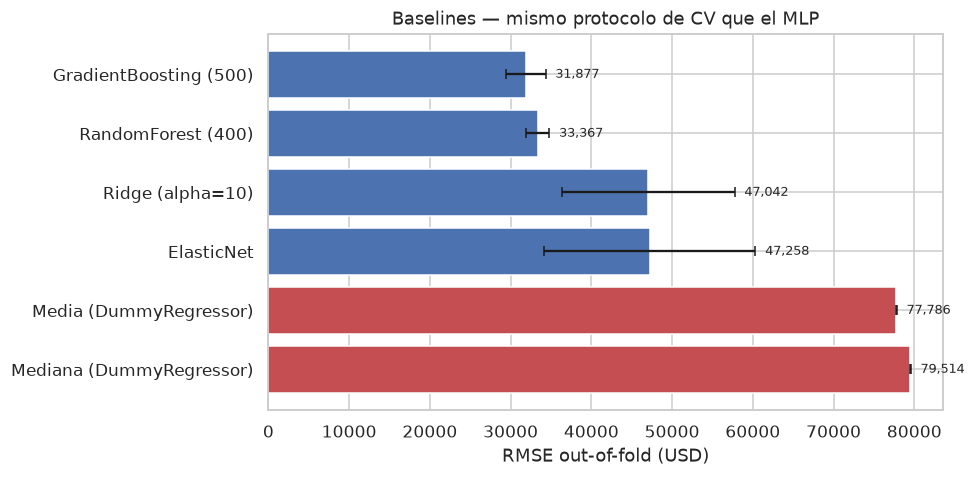

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
b = baselines.sort_values("RMSE", ascending=False)
colores = ["#C44E52" if "Dummy" in n else "#4C72B0" for n in b["modelo"]]
ax.barh(b["modelo"], b["RMSE"], xerr=b["std entre semillas"], color=colores, capsize=3)
for i, (v, s) in enumerate(zip(b["RMSE"], b["std entre semillas"])):
    ax.text(v + s + 1200, i, f"{v:,.0f}", va="center", fontsize=8.5)
ax.set_xlabel("RMSE out-of-fold (USD)")
ax.set_title("Baselines — mismo protocolo de CV que el MLP")
fig.tight_layout(); fig.savefig(FIGURES / "14_baselines.png"); plt.show()

In [5]:
piso = baselines["RMSE"].min()
techo = baselines.loc[baselines["modelo"].str.contains("Media"), "RMSE"].iloc[0]
mejor = baselines.loc[baselines["RMSE"].idxmin(), "modelo"]

print("Marco de referencia para el MLP")
print("=" * 52)
print(f"  Techo (no aprender nada)  : {techo:,.0f} USD")
print(f"  Mejor baseline ({mejor}) : {piso:,.0f} USD")
print(f"\n  Un MLP por encima de {techo:,.0f} no aprendió nada.")
print(f"  Un MLP por debajo de {piso:,.0f} supera al mejor modelo clásico.")
print(f"\nObjetivo del notebook 04: quedar por debajo de {piso:,.0f} USD.")

baselines.to_csv(ROOT / "reports" / "baselines.csv", index=False)
print("\nGuardado en reports/baselines.csv → lo lee el notebook 04")

Marco de referencia para el MLP
  Techo (no aprender nada)  : 77,786 USD
  Mejor baseline (GradientBoosting (500)) : 31,877 USD

  Un MLP por encima de 77,786 no aprendió nada.
  Un MLP por debajo de 31,877 supera al mejor modelo clásico.

Objetivo del notebook 04: quedar por debajo de 31,877 USD.

Guardado en reports/baselines.csv → lo lee el notebook 04
